In [1]:
import warnings, sys, os, gc
from os.path import join
warnings.filterwarnings("ignore")
os.environ["CUDA_VISIBLE_DEVICES"] = ""

# import torch; print(torch.cuda.is_available())

import libemg
from libemg.datasets import get_dataset_list
from libemg.feature_extractor import FeatureExtractor

import numpy as np, pandas as pd
import random, copy, time
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

from utils import *
from models import *

SEED = 13; random.seed(SEED); np.random.seed(SEED)
GENERATOR = torch.manual_seed(SEED)
MMAP_MODE = 'r'; SAVE_CHKP = True

Bluepy not installed...


In [ ]:
results = {}

REPS = list(map(int, '2,3,15'.split(',')))
for i, MODEL in enumerate(["lda_segmented_within", "mlp_segmented_within", "cnn_segmented_within", "cnn_segmented_within_ft"]):
    accs = []
    act_accs = []
    bal_accs = []

    for NAME in [f'{MODEL}_{i}' for i in REPS]:
        res = np.load((f"{CHECKPOINT_PATH}/{NAME}/results.npy"), allow_pickle=True)
        df = pd.DataFrame(res.tolist())
        idx = slice(VAL_CUTOFF, 612)
        acc = df['acc_mean'][idx]
        act_acc = df['act_acc_mean'][idx]
        bal_acc = df['bal_acc_mean'][idx]
        accs.append(acc.mean())
        act_accs.append(act_acc.mean())
        bal_accs.append(bal_acc.mean())

    MODEL = MODEL.replace('ft', '_FT')
    MODEL = MODEL.replace('within', '')
    results[f'{MODEL}_{i}'] = {}
    results[f'{MODEL}_{i}']['accuracy'] = acc.mean()
    results[f'{MODEL}_{i}']['active accuracy'] = act_acc.mean()
    results[f'{MODEL}_{i}']['balanced accuracy'] = bal_acc.mean()

results
    # name = NAME
    # tag = NAME
    # os.makedirs(f"{FIGURE_PATH}", exist_ok=True)
    # os.makedirs(f"{FIGURE_PATH}/{name}/", exist_ok=True)

    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 7), dpi=200)
    # fig.suptitle(f"{tag} | Mean Acc {acc.mean():.2f} ± {np.std(acc):.2f} \
    #                 | Mean Actv {act_acc.mean():.2f} ± {np.std(act_acc):.2f}")

    # ax1.bar(np.arange(n_subj), np.sort(acc))
    # ax1.axhline(acc.mean(), color='red', linestyle='--')
    # ax1.set_title('Per Subject Accuracy')

    # ax2.bar(np.arange(n_subj), np.sort(act_acc))
    # ax2.axhline(act_acc.mean(), color='red', linestyle='--')
    # ax2.set_title('Per Subject Active Accuracy')

    # fig.tight_layout(rect=[0, 0, 1, 0.95])
    # fig.savefig(f"{FIGURE_PATH}/{name}/{tag}.jpg")
    # fig.clf()
    # plt.close(fig)

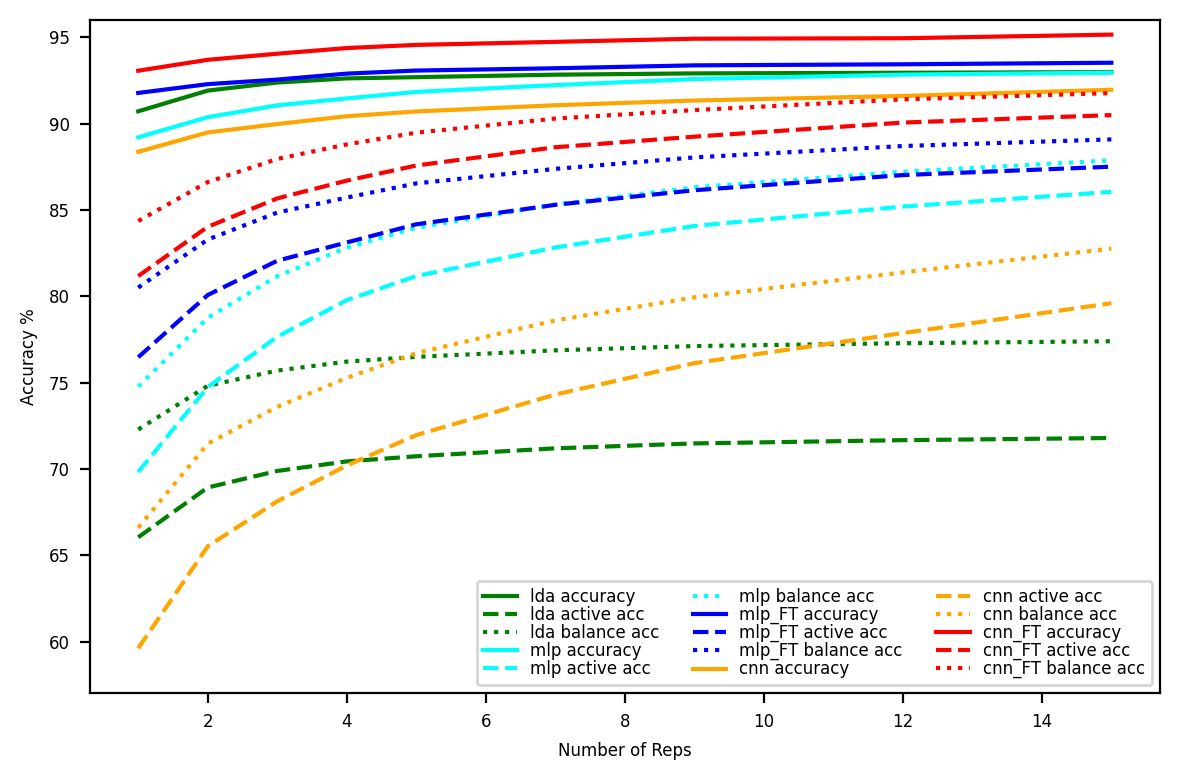

In [11]:
colors = ['green', 'cyan', 'blue', 'orange', 'red']
fig = plt.figure()
fig.set_dpi(200)

REPS = list(map(int, '1,2,3,4,5,7,9,12,15'.split(',')))
for i, MODEL in enumerate(["lda_raw_within", 
                           "mlp_raw_within", "mlp_raw_within_ft", 
                           "cnn_raw_within", "cnn_raw_within_ft"]):
    accs = []
    act_accs = []
    bal_accs = []

    for NAME in [f'{MODEL}_{i}' for i in REPS]:
        res = np.load((f"{CHECKPOINT_PATH}/{NAME}/results.npy"), allow_pickle=True)
        df = pd.DataFrame(res.tolist())
        idx = slice(VAL_CUTOFF, 612)
        acc = df['acc_mean'][idx]
        act_acc = df['act_acc_mean'][idx]
        bal_acc = df['bal_acc_mean'][idx]
        accs.append(acc.mean())
        act_accs.append(act_acc.mean())
        bal_accs.append(bal_acc.mean())

    MODEL = MODEL.replace('_', '')
    MODEL = MODEL.replace('raw', '')
    MODEL = MODEL.replace('ft', '_FT')
    MODEL = MODEL.replace('within', '')
    plt.plot(REPS, accs, label=f'{MODEL} accuracy', linestyle='solid', color=colors[i])
    plt.plot(REPS, act_accs, label=f'{MODEL} active acc', linestyle='dashed', color=colors[i])
    plt.plot(REPS, bal_accs, label=f'{MODEL} balance acc', linestyle='dotted', color=colors[i])
    plt.ylim(57, 96)
    plt.xlabel("Number of Reps", fontsize=6)
    plt.ylabel("Accuracy %", fontsize=6)
    plt.tick_params(axis='both', labelsize=6) 
    fig.set_facecolor("white")
    plt.tight_layout()
    plt.legend(fontsize=6, handlelength=2, 
               ncol=3, labelspacing=0.0,
               loc='lower right')

fig.show()

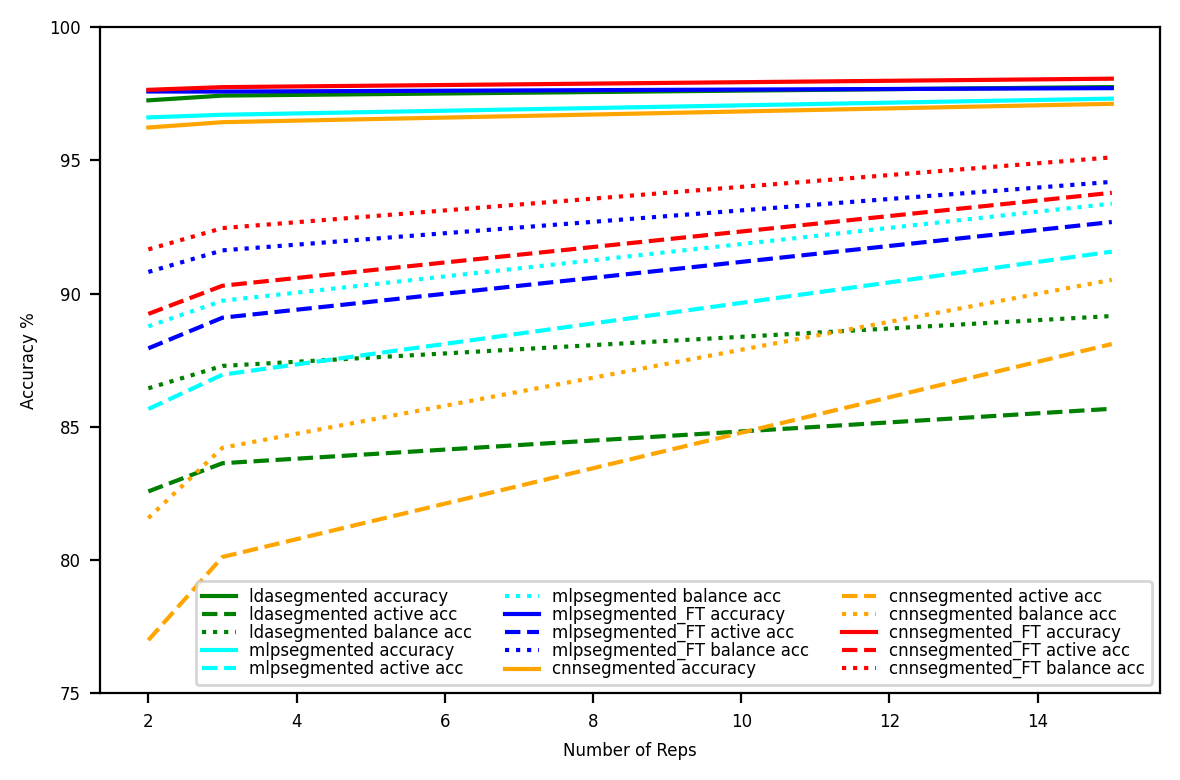

In [6]:
colors = ['green', 'cyan', 'blue', 'orange', 'red']
fig = plt.figure()
fig.set_dpi(200)

REPS = list(map(int, '2,3,15'.split(',')))
for i, MODEL in enumerate(["lda_segmented_within", 
                           "mlp_segmented_within", "mlp_segmented_within_ft", 
                           "cnn_segmented_within", "cnn_segmented_within_ft"]):
    accs = []
    act_accs = []
    bal_accs = []

    for NAME in [f'{MODEL}_{i}' for i in REPS]:
        res = np.load((f"{CHECKPOINT_PATH}/{NAME}/results.npy"), allow_pickle=True)
        df = pd.DataFrame(res.tolist())
        idx = slice(VAL_CUTOFF, 612)
        acc = df['acc_mean'][idx]
        act_acc = df['act_acc_mean'][idx]
        bal_acc = df['bal_acc_mean'][idx]
        accs.append(acc.mean())
        act_accs.append(act_acc.mean())
        bal_accs.append(bal_acc.mean())

    MODEL = MODEL.replace('_', '')
    MODEL = MODEL.replace('raw', '')
    MODEL = MODEL.replace('ft', '_FT')
    MODEL = MODEL.replace('within', '')
    plt.plot(REPS, accs, label=f'{MODEL} accuracy', linestyle='solid', color=colors[i])
    plt.plot(REPS, act_accs, label=f'{MODEL} active acc', linestyle='dashed', color=colors[i])
    plt.plot(REPS, bal_accs, label=f'{MODEL} balance acc', linestyle='dotted', color=colors[i])
    plt.ylim(75, 100)
    plt.xlabel("Number of Reps", fontsize=6)
    plt.ylabel("Accuracy %", fontsize=6)
    plt.tick_params(axis='both', labelsize=6) 
    fig.set_facecolor("white")
    plt.tight_layout()
    plt.legend(fontsize=6, handlelength=2, 
               ncol=3, labelspacing=0.0,
               loc='lower right')

fig.show()

In [2]:
SAMPLING_RATE = 200
FEATURE_LIST = ['WENG']
FEATURE_DIC = {'WENG_fs': SAMPLING_RATE}
train_windows = np.load(join(PICKLE_PATH, 'train_windows.npy'), mmap_mode=MMAP_MODE)[:10]
feature_extractor = FeatureExtractor()
train_windows = feature_extractor.extract_features(FEATURE_LIST, train_windows, array=True,
                              fix_feature_errors=False, feature_dic=FEATURE_DIC).reshape((
                                  train_windows.shape[0], -1))
n_features = train_windows.shape[1]
model = MLP(n_features)
print(model, f"\nParameters count: {count_params(model):,}")

model = CNNBaseline()
print(model, f"\nParameters count: {count_params(model):,}")

model = LSTM()
print(model, f"\nParameters count: {count_params(model):,}")

model = TransformerEMG()
print(model, f"\nParameters count: {count_params(model):,}")

model = CNN()
print(model, f"\nParameters count: {count_params(model):,}")

MLP(
  (fc1): Linear(in_features=48, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc_emb): Linear(in_features=128, out_features=64, bias=True)
  (classifier): Linear(in_features=64, out_features=5, bias=True)
  (drop): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
) 
Parameters count: 197,893
CNNBaseline(
  (conv1): Conv1d(8, 64, kernel_size=(8,), stride=(1,), padding=same)
  (conv2): Conv1d(64, 128, kernel_size=(6,), stride=(1,), padding=same)
  (conv3): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=same)
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc_emb): Linear(in_features=128, out_features=128, bias=True)
  (classifier): Linear(in_features=128, out_features=5, bias=True)
  (relu): ReLU()
  (drop): Dropout(p=0.2, inplace=False)
) 
Parameters count: 152,773
LSTM(
  (lstm): LSTM(8, 128, num_layers=2, 